In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from category_encoders import OneHotEncoder
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge

import seaborn as sns

In [30]:
df = pd.read_csv("india_realistic_salary_dataset.csv")

In [31]:
df.head()

,job_role,city,education,college_tier,industry,company_size,gender,years_experience,age,performance_rating,num_skills,base_salary,bonus,total_ctc
0,Business Analyst,Bangalore,MTech/Master,Tier 3,Product Based,MNC,Male,4.3,27.0,3.66,4,2741239.0,648217.0,3.389456e+06
1,Frontend Developer,Bangalore,BTech/Bachelor,Tier 2,FinTech,MNC,Male,10.6,35.0,3.50,6,3440016.0,755362.0,1.108712e+07
2,Software Engineer,Ahmedabad,MBA,Tier 3,Product Based,Startup,Male,4.4,28.0,3.61,3,1933149.0,102980.0,2.036129e+06
3,Backend Developer,Mumbai,MTech/Master,Tier 1,E-Commerce,Startup,Male,3.2,29.0,3.14,7,2818909.0,182794.0,3.001703e+06
4,Backend Developer,Kolkata,BTech/Bachelor,Tier 1,EdTech,Mid-size,Male,3.4,25.0,3.91,3,1644130.0,154154.0,1.798284e+06


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_role            7000 non-null   object 
 1   city                7000 non-null   object 
 2   education           6580 non-null   object 
 3   college_tier        7000 non-null   object 
 4   industry            7000 non-null   object 
 5   company_size        7000 non-null   object 
 6   gender              7000 non-null   object 
 7   years_experience    7000 non-null   float64
 8   age                 7000 non-null   float64
 9   performance_rating  6580 non-null   float64
 10  num_skills          7000 non-null   int64  
 11  base_salary         7000 non-null   float64
 12  bonus               7000 non-null   float64
 13  total_ctc           7000 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 765.8+ KB


Text(0.5, 1.0, 'Repartition of Total annual compensation (INR)')

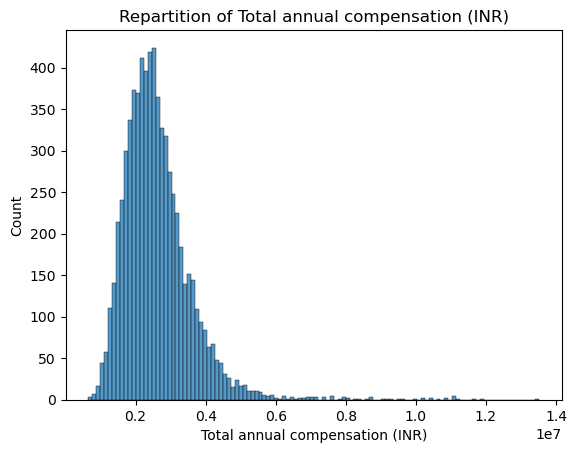

In [33]:
sns.histplot(data=df, x="total_ctc")
plt.xlabel("Total annual compensation (INR)")
plt.title("Repartition of Total annual compensation (INR)")

In [34]:
df.describe()

,years_experience,age,performance_rating,num_skills,base_salary,bonus,total_ctc
count,7000.000000,7000.000000,6580.000000,7000.000000,7.000000e+03,7.000000e+03,7.000000e+03
mean,5.147314,28.185143,3.397119,5.007857,2.235151e+06,3.336118e+05,2.632563e+06
std,3.629485,4.137204,0.777509,2.216544,7.115175e+05,1.724811e+05,1.015443e+06
min,0.000000,17.000000,1.000000,1.000000,5.593790e+05,4.969300e+04,6.531570e+05
25%,2.200000,25.000000,2.870000,3.000000,1.733223e+06,1.995942e+05,1.978098e+06
50%,4.900000,28.000000,3.400000,5.000000,2.143170e+06,3.041610e+05,2.473262e+06
75%,7.600000,31.000000,3.930000,6.000000,2.641624e+06,4.370062e+05,3.065932e+06
max,22.200000,45.000000,5.000000,15.000000,6.415470e+06,1.232911e+06,1.352317e+07


## Visualizing for Removing high-low cardinality categorical variables

In [35]:
df.select_dtypes("object").nunique()

job_role        13
city            10
education        4
college_tier     3
industry         7
company_size     3
gender           2
dtype: int64

Text(0.5, 1.0, 'Repartition of Total annual compensation (INR) by Gender')

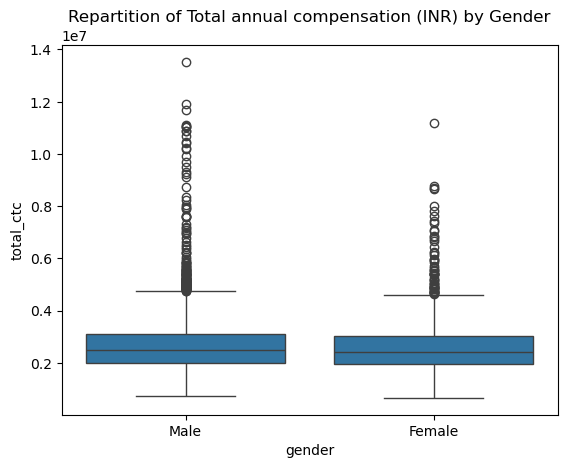

In [36]:
sns.boxplot(data=df, y="total_ctc", x="gender")
plt.title("Repartition of Total annual compensation (INR) by Gender")

Text(0.5, 1.0, 'Repartition of Total annual compensation (INR) by Company size')

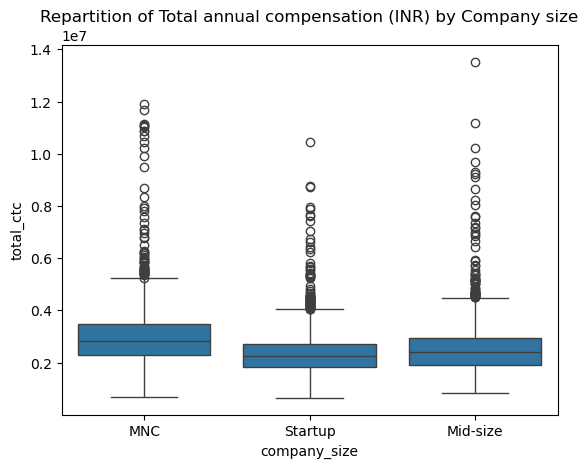

In [37]:
sns.boxplot(data=df, y="total_ctc", x="company_size")
plt.title("Repartition of Total annual compensation (INR) by Company size")

Text(0.5, 1.0, 'Repartition of Total annual compensation (INR) by College Tier')

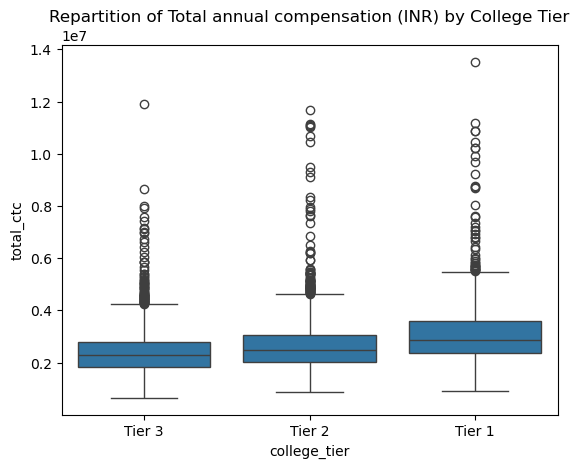

In [38]:
sns.boxplot(data=df, y="total_ctc", x="college_tier")
plt.title("Repartition of Total annual compensation (INR) by College Tier")

Text(0.5, 1.0, 'Repartition of Total annual compensation (INR) by education')

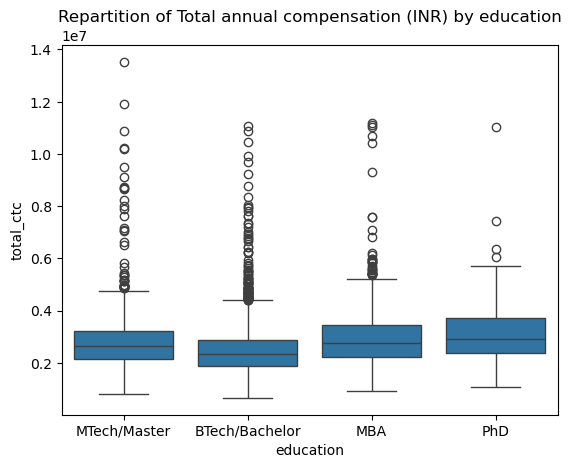

In [39]:
sns.boxplot(data=df, y="total_ctc", x="education")
plt.title("Repartition of Total annual compensation (INR) by education")

__Conclusion__ : Gender, college_tier and company_size will be delete as low cardinality categorial variable and aren't influence Total annual compensation

Fortunelly, we will keep __education,job_role, city and industry__

In [40]:
df.drop(
    columns=["gender", "college_tier", "company_size"],
inplace=True)

## Multi collinearity variables

In [41]:
corr = df.select_dtypes("float64").drop(columns="total_ctc").corr()

<Axes: >

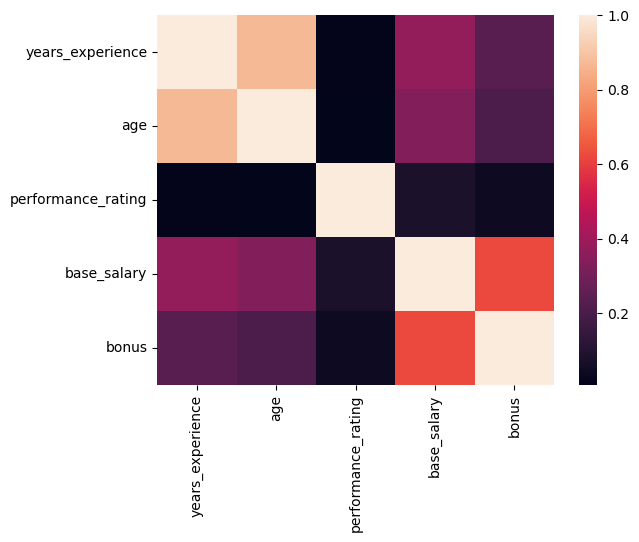

In [42]:
sns.heatmap(corr)

In [43]:
df.drop(columns="age", inplace=True)

In [56]:
sns.scatterplot(data=df, x="performance_rating", y="bonus"])
plt.xlabel("Performance rating")
plt.ylabel("Bonus")
plt.title("Bonus as function of performance rating")

SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' (3993177473.py, line 1)